<a href="https://colab.research.google.com/github/vicfior/transformer-serie-temporal-bitcoin/blob/main/Previsao_de_criptomoedas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Previsão de Preços de Bitcoin com Transformer

Modelo Transformer aplicado à previsão do preço de fechamento diário do Bitcoin (BTC-USD),
adaptado a partir de um exercício de curso originalmente construído sobre uma série senoidal
sintética. O notebook documenta o processo completo: preparação dos dados, arquitetura,
treinamento, um diagnóstico honesto contra um baseline ingênuo, a identificação e correção de
um efeito de atraso (lag) causado pelo tamanho da janela, e a mitigação do colapso cíclico em
previsões de longo prazo via injeção de ruído calibrado.

*Transformer model applied to Bitcoin (BTC-USD) daily closing price forecasting, adapted from
a coursework exercise originally built on synthetic sinusoidal data. This notebook documents
the full process: data preparation, architecture, training, an honest comparison against a
naive baseline, diagnosing and fixing a window-size lag effect, and mitigating the cyclic
collapse of long-horizon forecasts via calibrated noise injection.*


In [56]:
from logging import warn
# imports

import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import yfinance as yf

In [57]:
plt.style.use('classic')
plt.rcParams['figure.figsize'] = (15,6)

In [58]:
from torch.cuda import is_available
if torch.cuda.is_available():
  device = torch.device("cuda")
  print("Dispositivo selecionado: GPU NVIDIA (CUDA)")

else:
  device = torch.device("cpu")
  print("Dispositivo selecionado: CPU")

print(f'Usando dispositivo: {device}')

Dispositivo selecionado: GPU NVIDIA (CUDA)
Usando dispositivo: cuda


In [59]:
def carrega_serie_bitcoin(ticker = 'BTC-USD', periodo =  '5y', intervalo = '1d'):
  df = yf.download(ticker, period = periodo, interval = intervalo, progress = False)

  serie = df['Close'].values.flatten()

  serie = serie[~np.isnan(serie)]

  return serie.astype(np.float32)

In [60]:
serie = carrega_serie_bitcoin()

In [61]:
len(serie)

1827

In [62]:
type(serie)

numpy.ndarray

In [63]:
serie[0:5]

array([52633.535, 46811.13 , 46091.39 , 46391.42 , 44883.91 ],
      dtype=float32)

# Visualizando os dados da série temporal

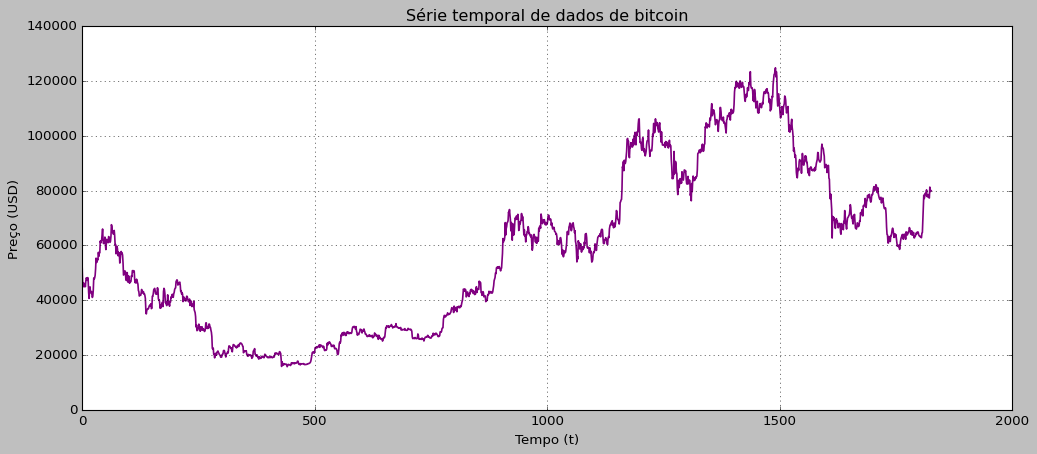

In [64]:
t = np.arange(len(serie))

plt.figure(figsize=(15,6))
plt.plot(t,serie,color = 'purple', linewidth = 1.5)
plt.title("Série temporal de dados de bitcoin")
plt.xlabel("Tempo (t)")
plt.ylabel("Preço (USD)")
plt.grid(True)
plt.show()

# Divisão em treino e teste

In [65]:
input_window = 50

In [66]:
cutoff = int(len(serie)*0.8)

In [67]:
serie_train = serie[:cutoff]
serie_test = serie[cutoff:]

# Normalização dos dados

In [68]:
scaler = MinMaxScaler(feature_range=(-1,1))

In [69]:
scaler.fit(serie_train.reshape(-1,1))

MinMaxScaler(feature_range=(-1, 1))

In [70]:
serie_train_scaled = scaler.transform(serie_train.reshape(-1,1)).astype(np.float32)

In [71]:
serie_test_scaled = scaler.transform(serie_test.reshape(-1,1)).astype(np.float32)

## Criando sequência de dados

In [72]:
def cria_sequencias(dados, input_window):
  sequencias = []
  L = len(dados)
  for i in range(L - input_window):
    seq = dados[i:i + input_window]
    label = dados[i + input_window:i + input_window + 1]
    sequencias.append((seq, label))
  return sequencias

In [73]:
train_sequences = cria_sequencias(serie_train_scaled, input_window)
test_sequences = cria_sequencias(serie_test_scaled, input_window)

In [74]:
len(train_sequences)

1411

In [75]:
len(test_sequences)

316

In [76]:
train_sequences[0][0].shape

(50, 1)

In [77]:
train_sequences[0][1].shape

(1, 1)

In [78]:
train_sequences[0]

(array([[-0.31485027],
        [-0.42311692],
        [-0.43650037],
        [-0.43092132],
        [-0.45895326],
        [-0.45304853],
        [-0.43702328],
        [-0.4574812 ],
        [-0.41788507],
        [-0.39773095],
        [-0.40503848],
        [-0.4146304 ],
        [-0.39583397],
        [-0.4147662 ],
        [-0.49688876],
        [-0.53686994],
        [-0.48330134],
        [-0.45874524],
        [-0.49696404],
        [-0.4992541 ],
        [-0.49010646],
        [-0.5081957 ],
        [-0.5305316 ],
        [-0.52067965],
        [-0.47927767],
        [-0.3988356 ],
        [-0.40637493],
        [-0.39729202],
        [-0.38031584],
        [-0.33565277],
        [-0.26412523],
        [-0.29304874],
        [-0.29003894],
        [-0.27143717],
        [-0.2750938 ],
        [-0.22464204],
        [-0.25148797],
        [-0.22619832],
        [-0.22767794],
        [-0.14823294],
        [-0.16128218],
        [-0.14898288],
        [-0.14019752],
        [-0

In [79]:
def converte_para_tensor(data):
  X = torch.tensor([item[0] for item in data], dtype=torch.float32)
  y = torch.tensor([item[1] for item in data], dtype= torch.float32)
  return X,y

In [80]:
X_train, y_train = converte_para_tensor(train_sequences)
X_test, y_test = converte_para_tensor(test_sequences)

## Criação dos dataloaders

In [81]:
batch_size = 32

In [82]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

In [83]:
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size= batch_size, shuffle=False)

# Função para positional encoding

In [84]:
class PositionalEncoding(nn.Module):
  def __init__(self, d_model, dropout = 0.1, max_len = 5000):
    super(PositionalEncoding, self).__init__()

    self.dropout = nn.Dropout(p = dropout)

    pe = torch.zeros(max_len, d_model)

    position = torch.arange(0, max_len, dtype = torch.float).unsqueeze(1)

    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(1000) / d_model))

    pe[:, 0::2] = torch.sin(position * div_term)

    pe[:, 1::2] = torch.cos(position * div_term)

    pe = pe.unsqueeze(0)

    self.register_buffer('pe',pe)

  def forward(self,x):
    x = x + self.pe[:, :x.size(1), :]
    return self.dropout(x)

In [85]:
class TimeSeriesTransformer(nn.Module):
  def __init__(self, input_dim = 1, d_model = 32, nhead = 4, num_layers = 4, dropout = 0.1):
    super(TimeSeriesTransformer, self).__init__()

    self.model_type = 'Transformer'
    self.d_model = d_model

    self.encoder = nn.Linear(input_dim, d_model)

    self.pos_encoder = PositionalEncoding(d_model, dropout)

    encoder_layers = nn.TransformerEncoderLayer(
        d_model = d_model,
        nhead = nhead,
        dim_feedforward = d_model * 4,
        dropout = dropout,
        batch_first = True
    )

    self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers = num_layers)

    self.decoder = nn.Linear(d_model, input_dim)

  def forward(self, src):
    src = self.encoder(src)*math.sqrt(self.d_model)

    src = self.pos_encoder(src)

    output = self.transformer_encoder(src)

    output = output[:, -1, :]

    output = self.decoder(output)

    return output

In [86]:
modelo_previsao_criptomoeda = TimeSeriesTransformer().to(device)

In [87]:
print(modelo_previsao_criptomoeda)

TimeSeriesTransformer(
  (encoder): Linear(in_features=1, out_features=32, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): Linear(in_features=32, out_features=1, bias=True)
)


## Função de erro e otimizador

In [88]:
criterion = nn.MSELoss()

In [89]:
optimizer = torch.optim.Adam(modelo_previsao_criptomoeda.parameters(), lr = 0.0005)

# Treinamento do modelo

In [90]:
epochs = 60

In [91]:
modelo_previsao_criptomoeda.train()

TimeSeriesTransformer(
  (encoder): Linear(in_features=1, out_features=32, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): Linear(in_features=32, out_features=1, bias=True)
)

In [92]:
%%time

for epoch in range(epochs):
  total_loss = 0
  pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

  for seq, label in pbar:
    seq, label = seq.to(device), label.to(device)

    optimizer.zero_grad()

    y_pred = modelo_previsao_criptomoeda(seq)

    loss = criterion(y_pred, label.squeeze(-1))

    loss.backward()

    optimizer.step()

    total_loss += loss.item()

    pbar.set_postfix({'loss': loss.item()})

  avg_loss = total_loss / len(train_loader)

  print(f"Epoch {epoch+1} concluída, Loss média: {avg_loss:.6f}")



Epoch 1/60: 100%|██████████| 45/45 [00:00<00:00, 77.03it/s, loss=0.0179]


Epoch 1 concluída, Loss média: 0.028380


Epoch 2/60: 100%|██████████| 45/45 [00:00<00:00, 80.28it/s, loss=0.0177]


Epoch 2 concluída, Loss média: 0.014145


Epoch 3/60: 100%|██████████| 45/45 [00:00<00:00, 77.84it/s, loss=0.0162]


...

Epoch 58 concluída, Loss média: 0.002298


Epoch 59/60: 100%|██████████| 45/45 [00:00<00:00, 77.92it/s, loss=0.00375]


Epoch 59 concluída, Loss média: 0.002089


Epoch 60/60: 100%|██████████| 45/45 [00:00<00:00, 76.11it/s, loss=0.00706]

Epoch 60 concluída, Loss média: 0.002251
CPU times: user 37.1 s, sys: 801 ms, total: 37.9 s
Wall time: 41 s


## Avaliação

In [93]:
modelo_previsao_criptomoeda.eval()

TimeSeriesTransformer(
  (encoder): Linear(in_features=1, out_features=32, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): Linear(in_features=32, out_features=1, bias=True)
)

In [94]:
all_predictions = []
all_actuals = []

In [95]:
with torch.no_grad():
  for seq, label in test_loader:
    seq, label = seq.to(device), label.to(device)

    y_pred = modelo_previsao_criptomoeda(seq)

    all_predictions.extend(y_pred.cpu().numpy())

    all_actuals.extend(label.cpu().numpy())

In [96]:
actual_predictions = scaler.inverse_transform(np.array(all_predictions))
y_test_original = scaler.inverse_transform(np.array(all_actuals).reshape(-1,1))

In [97]:
mse = mean_squared_error(y_test_original, actual_predictions)
rmse = mse**0.5
mae = mean_absolute_error(y_test_original, actual_predictions)

In [98]:
print('MSE:', mse)
print('RMSE:',rmse)
print('MAE:', mae)

MSE: 4654418.0
RMSE: 2157.410021298687
MAE: 1651.156005859375


In [99]:
mape = np.mean(np.abs((y_test_original - actual_predictions) / y_test_original)) * 100
print(f'MAPE: {mape:.2f}%')

MAPE: 2.14%


In [100]:
baseline_pred = y_test_original[:-1]
baseline_real = y_test_original[1:]
mae_baseline = np.mean(np.abs(baseline_real - baseline_pred))
print(f'MAE baseline (naive): {mae_baseline:.4f}')

MAE baseline (naive): 1270.4220


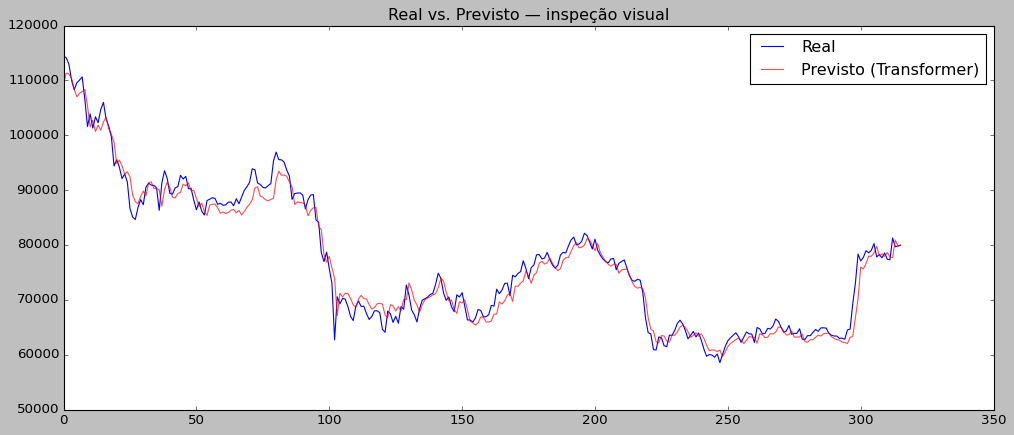

In [101]:
plt.figure(figsize=(15,6))
plt.plot(y_test_original, label='Real', color='blue')
plt.plot(actual_predictions, label='Previsto (Transformer)', color='red', alpha=0.7)
plt.legend()
plt.title('Real vs. Previsto — inspeção visual')
plt.show()

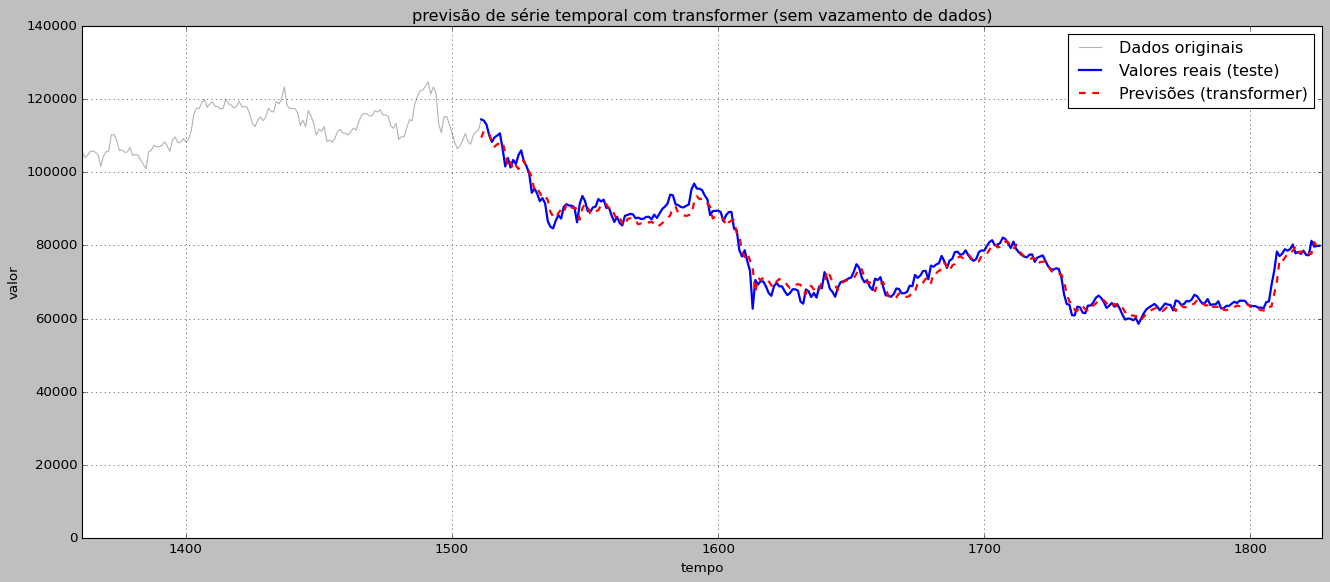

In [102]:
plt.figure(figsize=(20,8))
plt.plot(np.arange(len(serie)), serie, label = 'Dados originais', color='gray', alpha=0.6)

test_start = len(serie_train)

test_time_axis = np.arange(test_start + input_window, len(serie))

plt.plot(test_time_axis, y_test_original, label ='Valores reais (teste)', color='blue',linewidth=2)
plt.plot(test_time_axis, actual_predictions, label = 'Previsões (transformer)', color='red', linestyle = '--', linewidth=2)

plt.title("previsão de série temporal com transformer (sem vazamento de dados)")
plt.xlabel("tempo")
plt.ylabel("valor")
plt.legend()
plt.grid(True)

plt.xlim(test_start - 100, len(serie))
plt.show()

# Deploy

In [103]:
variacoes_diarias = np.diff(serie_train_scaled.flatten())
ruido_std = np.std(variacoes_diarias)
print(f'Desvio-padrão do ruído a injetar: {ruido_std:.5f}')

Desvio-padrão do ruído a injetar: 0.02817


In [104]:
def previsao_futuro_cripto(model, start_sequence, future_steps, ruido_std=0.0):
  model.eval()

  future_predictions = []

  current_sequence = start_sequence.clone().detach()

  with torch.no_grad():
    for i in range(future_steps):
      next_pred = modelo_previsao_criptomoeda(current_sequence.unsqueeze(0))

      if ruido_std > 0:
        ruido = torch.randn(1).item() * ruido_std
        next_pred = next_pred + ruido

      future_predictions.append(next_pred.item())

      next_pred_tensor = torch.tensor([[next_pred.item()]], device = device)
      current_sequence = torch.cat((current_sequence[1:], next_pred_tensor), dim=0)

  return np.array(future_predictions)

In [105]:
last_sequence_real = X_test[-1].to(device)
steps_to_forecast = 100
future_forecast_normalized = previsao_futuro_cripto(modelo_previsao_criptomoeda, last_sequence_real, steps_to_forecast, ruido_std)
future_forecast = scaler.inverse_transform(future_forecast_normalized.reshape(-1,1))

In [106]:
future_forecast[0:5]

array([[82427.30683262],
       [80546.9153743 ],
       [79895.68340628],
       [78985.49341656],
       [80251.47141201]])

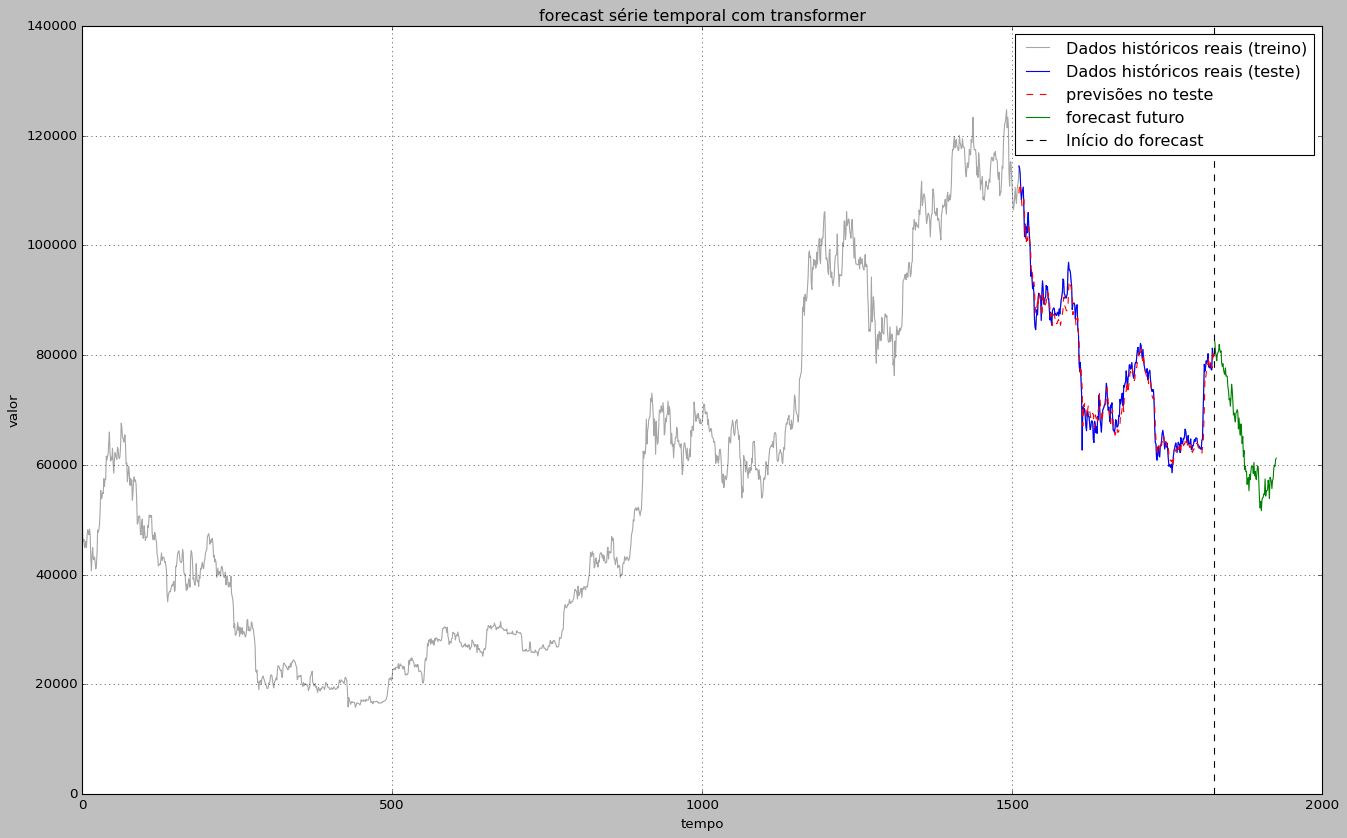

In [107]:
plt.figure(figsize = (20,12))

plt.plot(np.arange(len(serie)), serie, label = 'Dados históricos reais (treino)', color = 'gray', alpha=0.7)

test_start = len(serie_train)

plt.plot(test_time_axis, y_test_original, label = 'Dados históricos reais (teste)', color = 'blue')
plt.plot(test_time_axis, actual_predictions, label = 'previsões no teste', color = 'red', linestyle = '--')

future_time_axis = np.arange(len(serie), len(serie) + steps_to_forecast)
plt.plot(future_time_axis, future_forecast, label = 'forecast futuro', color = 'green', linewidth = 1)

plt.axvline(x = len(serie)-1, color = 'black', linestyle = '--', label = 'Início do forecast')

plt.title("forecast série temporal com transformer")
plt.xlabel('tempo')
plt.ylabel('valor')
plt.legend()
plt.grid(True)
plt.show()